In [1]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

### Classifying movie reviews: A binary classification example

#### The IMDb dataset

In [2]:
from keras.datasets import imdb

(train_data, train_labels), (test_data, test_labels) = imdb.load_data(
    num_words=10000
)

In [3]:
train_data[1]

[1,
 194,
 1153,
 194,
 8255,
 78,
 228,
 5,
 6,
 1463,
 4369,
 5012,
 134,
 26,
 4,
 715,
 8,
 118,
 1634,
 14,
 394,
 20,
 13,
 119,
 954,
 189,
 102,
 5,
 207,
 110,
 3103,
 21,
 14,
 69,
 188,
 8,
 30,
 23,
 7,
 4,
 249,
 126,
 93,
 4,
 114,
 9,
 2300,
 1523,
 5,
 647,
 4,
 116,
 9,
 35,
 8163,
 4,
 229,
 9,
 340,
 1322,
 4,
 118,
 9,
 4,
 130,
 4901,
 19,
 4,
 1002,
 5,
 89,
 29,
 952,
 46,
 37,
 4,
 455,
 9,
 45,
 43,
 38,
 1543,
 1905,
 398,
 4,
 1649,
 26,
 6853,
 5,
 163,
 11,
 3215,
 2,
 4,
 1153,
 9,
 194,
 775,
 7,
 8255,
 2,
 349,
 2637,
 148,
 605,
 2,
 8003,
 15,
 123,
 125,
 68,
 2,
 6853,
 15,
 349,
 165,
 4362,
 98,
 5,
 4,
 228,
 9,
 43,
 2,
 1157,
 15,
 299,
 120,
 5,
 120,
 174,
 11,
 220,
 175,
 136,
 50,
 9,
 4373,
 228,
 8255,
 5,
 2,
 656,
 245,
 2350,
 5,
 4,
 9837,
 131,
 152,
 491,
 18,
 2,
 32,
 7464,
 1212,
 14,
 9,
 6,
 371,
 78,
 22,
 625,
 64,
 1382,
 9,
 8,
 168,
 145,
 23,
 4,
 1690,
 15,
 16,
 4,
 1355,
 5,
 28,
 6,
 52,
 154,
 462,
 33,
 89,
 78,
 2

In [4]:
train_labels[0]

np.int64(1)

In [5]:
max([max(sequence) for sequence in train_data])

9999

#### Preparing the data

In [6]:
import numpy as np

def multi_hot_encode(sequences, num_classes):
    results = np.zeros((len(sequences), num_classes))
    for i, sequence in enumerate(sequences):
        results[i][sequence] = 1.0
    return results

In [7]:
# Small example to demonstrate how the multi_hot_encode function works:
input = [[1], [1, 2], [3, 1, 0]]
output = multi_hot_encode(input, num_classes=4)
output

array([[0., 1., 0., 0.],
       [0., 1., 1., 0.],
       [1., 1., 0., 1.]])

In [8]:
x_train = multi_hot_encode(train_data, num_classes=10000)
x_test = multi_hot_encode(test_data, num_classes=10000)

In [9]:
x_train[0]

array([0., 1., 1., ..., 0., 0., 0.], shape=(10000,))

In [10]:
x_train.shape

(25000, 10000)

In [11]:
y_train = train_labels.astype("float32")
y_test = test_labels.astype("float32")

#### Building your model

In [12]:
import keras
from keras import layers

model = keras.Sequential(
    [
        layers.Dense(10, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)

In [13]:
model.compile(
    optimizer="sgd",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

#### Validating your approach

In [14]:
history = model.fit(
    x_train,
    y_train,
    epochs=20,
    validation_split=0.2
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 680us/step - accuracy: 0.7413 - loss: 0.5806 - val_accuracy: 0.8266 - val_loss: 0.4739
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 502us/step - accuracy: 0.8429 - loss: 0.4115 - val_accuracy: 0.8512 - val_loss: 0.3773
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 506us/step - accuracy: 0.8647 - loss: 0.3412 - val_accuracy: 0.8624 - val_loss: 0.3381
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 505us/step - accuracy: 0.8788 - loss: 0.3041 - val_accuracy: 0.8702 - val_loss: 0.3176
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 498us/step - accuracy: 0.8895 - loss: 0.2793 - val_accuracy: 0.8758 - val_loss: 0.3054
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 568us/step - accuracy: 0.8979 - loss: 0.2602 - val_accuracy: 0.8790 - val_loss: 0.2970
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 527us/step - accuracy: 0.9057 - loss: 0.2449 - val_accuracy: 0.8810 - val_loss: 0.2908
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 528us/step - accuracy: 0.9105 - loss: 0.2322 - 

In [15]:
history_dict = history.history
history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

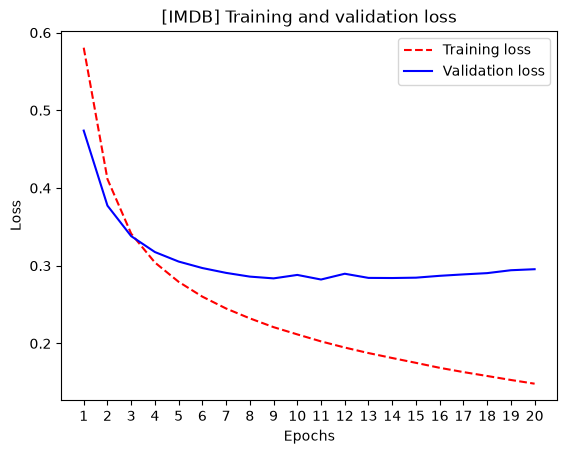

In [16]:
import matplotlib.pyplot as plt

history_dict = history.history
loss_values = history_dict["loss"]
val_loss_values = history_dict["val_loss"]
epochs = range(1, len(loss_values) + 1)
plt.plot(epochs, loss_values, "r--", label="Training loss")
plt.plot(epochs, val_loss_values, "b", label="Validation loss")
plt.title("[IMDB] Training and validation loss")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Loss")
plt.legend()
plt.show()

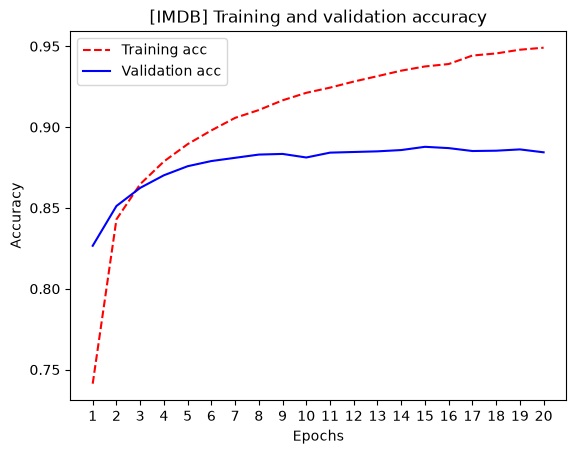

In [17]:
plt.clf()
acc = history_dict["accuracy"]
val_acc = history_dict["val_accuracy"]
plt.plot(epochs, acc, "r--", label="Training acc")
plt.plot(epochs, val_acc, "b", label="Validation acc")
plt.title("[IMDB] Training and validation accuracy")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [18]:
results = model.evaluate(x_test, y_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 315us/step - accuracy: 0.8788 - loss: 0.3108


In [19]:
results

[0.31079864501953125, 0.8788400292396545]

#### Using a trained model to generate predictions on new data

In [20]:
model.predict(x_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 222us/step


array([[0.19340809],
       [0.9998955 ],
       [0.44998443],
       ...,
       [0.0814939 ],
       [0.06001353],
       [0.38273767]], shape=(25000, 1), dtype=float32)